In [1]:
!git clone https://github.com/OmarAymanZaid/industrial-vision-defect-detection.git

Cloning into 'industrial-vision-defect-detection'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 81 (delta 37), reused 60 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 21.77 KiB | 2.72 MiB/s, done.
Resolving deltas: 100% (37/37), done.


In [2]:
%cd industrial-vision-defect-detection

/kaggle/working/industrial-vision-defect-detection


In [3]:
!git pull

Already up to date.


In [4]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 81.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 103.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 85.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 96.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 51.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uni

In [6]:
!python main.py


Loading dataset: bottle
Total images loaded: 100
100%|█████████████████████████████████████████| 100/100 [00:06<00:00, 16.51it/s]

=== Preprocessing Metrics ===

[GAUSSIAN]
MSE  : 3.3064
PSNR : 42.9686

[MEDIAN]
MSE  : 5.1614
PSNR : 41.0406


In [ ]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("/kaggle/working/industrial-vision-defect-detection/outputs/preprocessing/bottle/sample_gaussian.png")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
/kaggle/working/industrial-vision-defect-detection/outputs/preprocessing/bottle

In [7]:
import os
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict

def visualize_preprocessing(folder):
    files = os.listdir(folder)

    # Group files by sample ID
    groups = defaultdict(dict)

    for f in files:
        if not f.endswith(".png"):
            continue

        parts = f.split("_")

        # Expect format: sample_0_gray.png
        if len(parts) < 3:
            continue

        sample_id = parts[1]
        key = parts[2].split(".")[0]  # gray / gaussian / median

        groups[sample_id][key] = os.path.join(folder, f)

    sample_ids = sorted(groups.keys(), key=lambda x: int(x))
    num_samples = len(sample_ids)

    plt.figure(figsize=(10, 4 * num_samples))

    for i, sample_id in enumerate(sample_ids):
        data = groups[sample_id]

        gray = cv2.imread(data.get("gray", ""), cv2.IMREAD_GRAYSCALE)
        gaussian = cv2.imread(data.get("gaussian", ""), cv2.IMREAD_GRAYSCALE)
        median = cv2.imread(data.get("median", ""), cv2.IMREAD_GRAYSCALE)

        row = i * 3

        # Gray
        plt.subplot(num_samples, 3, row + 1)
        if gray is not None:
            plt.imshow(gray, cmap='gray')
        plt.title(f"Sample {sample_id} - Gray")
        plt.axis('off')

        # Gaussian
        plt.subplot(num_samples, 3, row + 2)
        if gaussian is not None:
            plt.imshow(gaussian, cmap='gray')
        plt.title(f"Sample {sample_id} - Gaussian")
        plt.axis('off')

        # Median
        plt.subplot(num_samples, 3, row + 3)
        if median is not None:
            plt.imshow(median, cmap='gray')
        plt.title(f"Sample {sample_id} - Median")
        plt.axis('off')

    plt.suptitle("Preprocessing Comparison", fontsize=16)
    plt.tight_layout()
    plt.show()

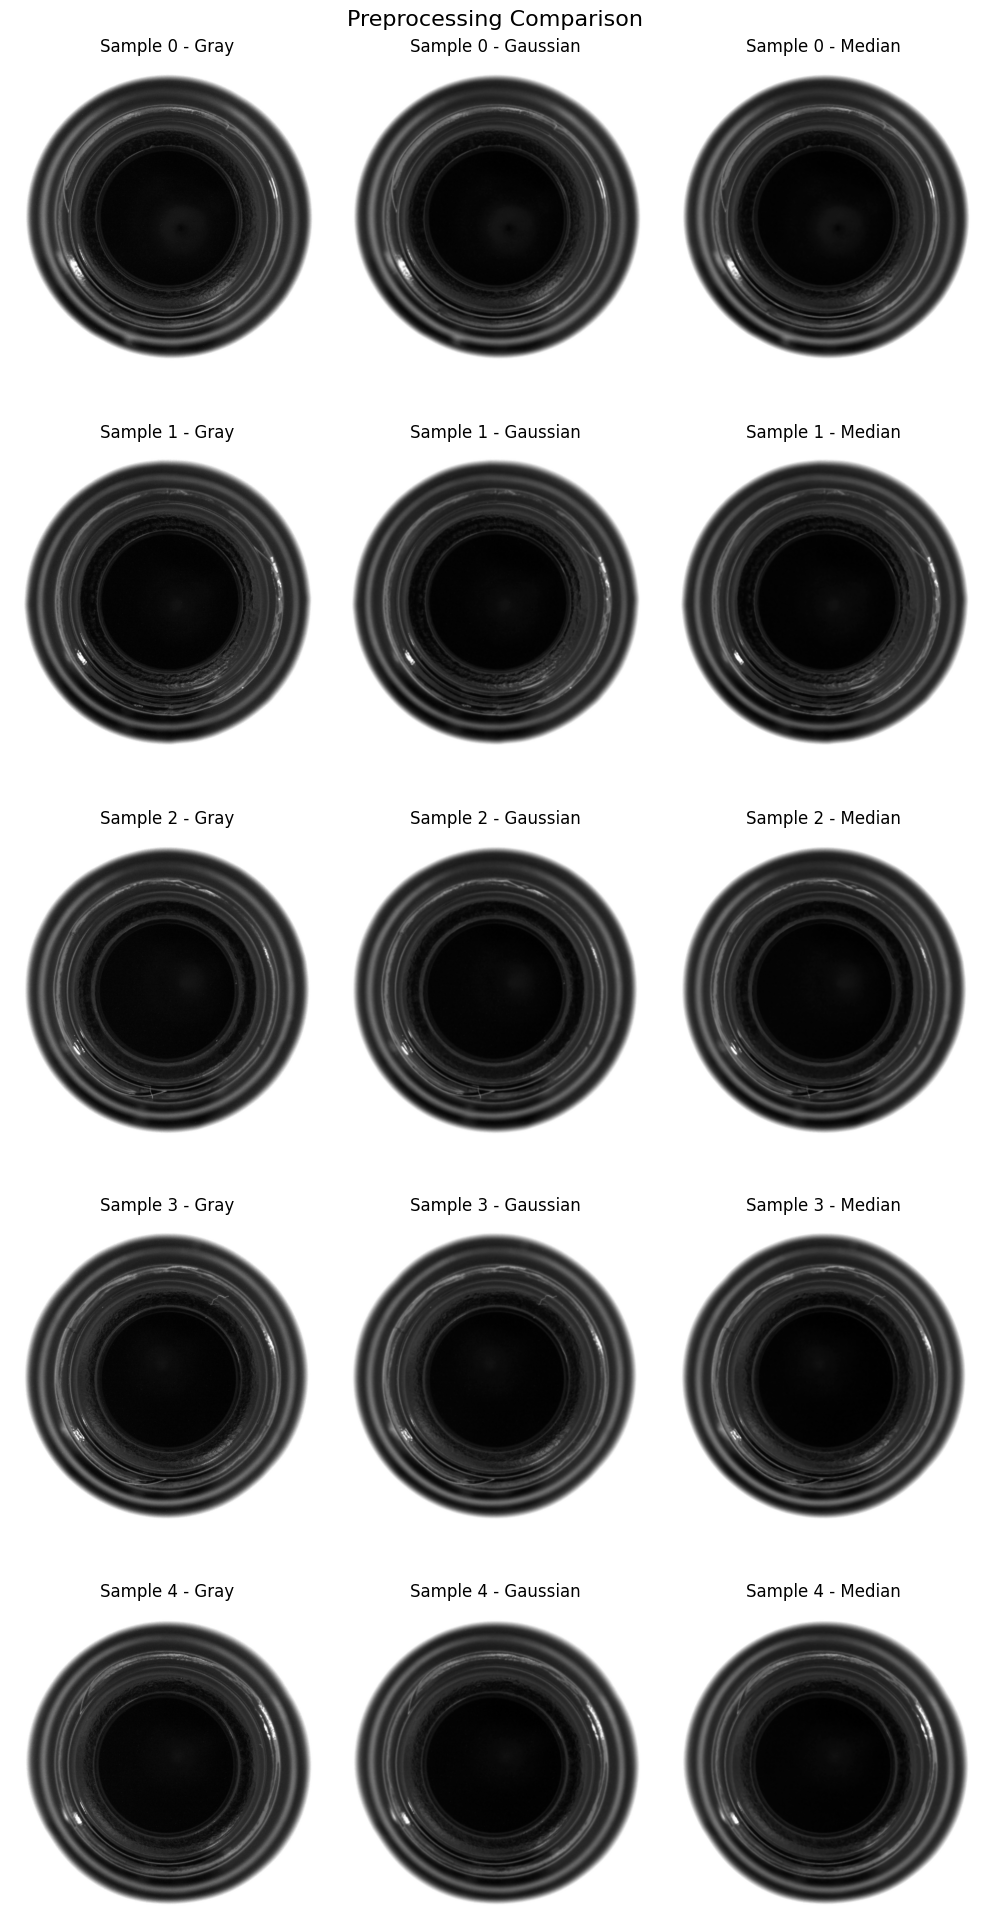

In [8]:
visualize_preprocessing(
    "/kaggle/working/industrial-vision-defect-detection/outputs/preprocessing/bottle"
)